In [1]:
from qutip import *
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from IPython.display import HTML
from tqdm.notebook import trange
import cProfile, pstats, io
from pstats import SortKey
import warnings
import sys
sys.path.append( '../src' )
from QFINumerics import QFI, genChannel, searchForState, calc_for_state, FI_observable

/home/dominic/software-projects/lab-repos/covert-quantum-analysis/notebooks/../src/QFINumerics.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange


In [2]:
#qutip.settings.core.atol=1e-60
#utip.settings.core.rtol=1e-60

In [3]:
state = searchForState()

  0%|          | 0/20000 [00:00<?, ?it/s]

In [4]:
n = tensor(num(5),identity(5),identity(6))
chan = genChannel()
pth0 = thermal_dm(5,(1-.1)*.1)
rho = vector_to_operator(chan*operator_to_vector(state.proj()))
rel_ent = entropy_relative(pth0,rho.ptrace([0]),tol=1e-50)
max_QFI = QFI(rho,n)
print(rel_ent)
print(max_QFI)

0.00998691206630925
0.18036706969375152


In [5]:
testfun = lambda eta,n_th,n_sq: (8*eta*n_sq*(n_sq + 1)*(4*eta*n_sq*(n_sq + 1) - (eta*n_sq + n_sq - n_th*(eta - 1) + 1)**2)/(4*eta*n_sq*(n_sq + 1) - (4*eta*n_sq*(n_sq + 1) - np.sqrt(-4*eta*n_sq*(n_sq + 1) + (eta*n_sq + n_sq + n_th*(1 - eta) + 1)**2)*(-eta*n_sq + n_sq + n_th*(eta - 1)) + (eta*n_sq + n_sq - n_th*(eta - 1) + 1)**2)*(4*eta*n_sq*(n_sq + 1) - np.sqrt(-4*eta*n_sq*(n_sq + 1) + (eta*n_sq + n_sq + n_th*(1 - eta) + 1)**2)*(eta*n_sq - n_sq + n_th*(1 - eta)) + (eta*n_sq + n_sq + n_th*(1 - eta) + 1)**2) - (eta*n_sq + n_sq - n_th*(eta - 1) + 1)**2))

In [6]:
alttest = lambda eta,n_th,n_sq: (4*eta*n_sq*(-n_sq - 1)/(2*eta*n_sq*n_th + eta*n_sq + eta*n_th - 2*n_sq*n_th - n_sq - n_th - 1))

In [7]:
test3 = lambda eta,n_th,n_sq:4*(eta**2*n_sq*(n_sq+1) + eta*(1-eta)*(n_th+1)*n_sq + eta*(1-eta)*n_th*(n_sq+1))

In [8]:
dim = 10
nth = .1
a = destroy(dim)
ad = a.dag()
iden = identity(dim)
pth = thermal_dm(dim,nth)
n = tensor(num(dim),iden)
a1 = tensor(a,iden)
theta = np.pi/2
zeroket = basis(dim,0)
oneket = basis(dim,1)
twoket = basis(dim,2)

In [9]:
nth = .001
eta = .00005
nsq = 3
xsi = 2*np.arcsinh(np.sqrt(nsq))
S = squeezing(tensor(a,iden),tensor(iden,a),xsi)
sq = S*tensor(zeroket,zeroket)
nsqad = expect(n,sq)
print(nsqad)
print(testfun(eta,nth,nsqad))
print(alttest(eta,nth,nsqad))
print(test3(eta,nth,nsqad))
print(calc_for_state(sq.proj(),n,a1,[dim,nth,eta]))

2.7181805883424377
0.0005421280025319443
0.0005427165321875355
0.0005449972105973212
[np.float64(6.142846104143472e-05), np.float64(0.0019544866366272323)]


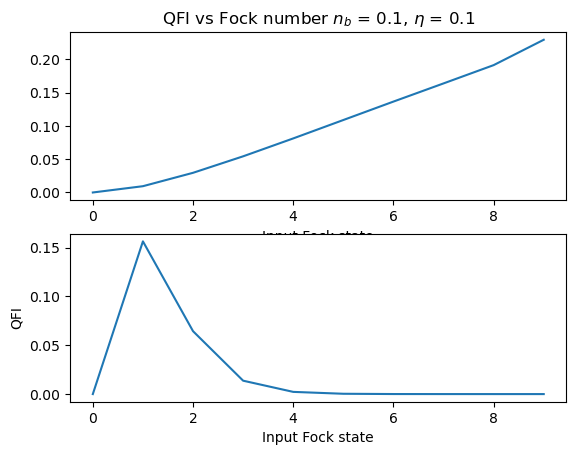

In [10]:
QFIs = np.zeros(dim)
REs = np.zeros(dim)
nth = .1
eta = .1
for i in range(dim):
    nket = basis(dim,i)
    unnorm = tensor(zeroket,nket) + tensor(nket,zeroket)
    statet = unnorm.proj().unit()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[1].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].set_title(r'QFI vs Fock number $n_b$ = {nb}, $\eta$ = {eta}'.format(nb=nth,eta=eta))
ax[0].plot(REs)
ax[1].plot(QFIs)

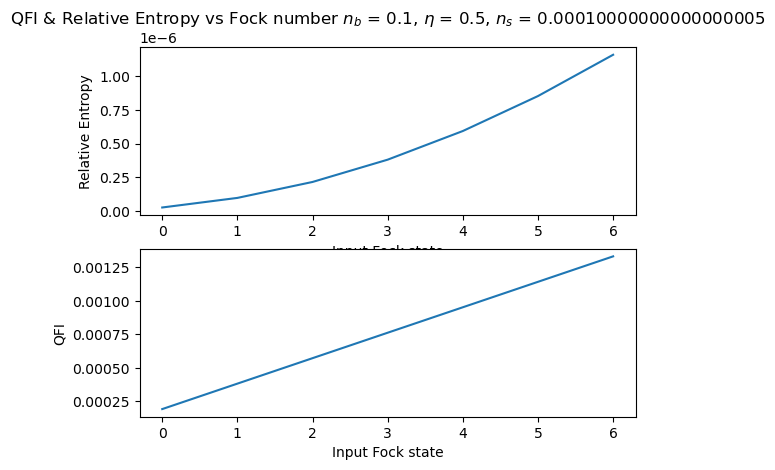

In [11]:
maxphotons = 7
QFIs = np.zeros(maxphotons)
REs = np.zeros(maxphotons)
nth = .1
eta = .5
xsi = 2*np.arcsinh(np.sqrt(.0001))
S = squeezing(tensor(a,iden),tensor(iden,a),xsi)
sq = S*tensor(zeroket,zeroket)
for i in range(maxphotons):
    unnorm = a1**i * sq
    statet = unnorm.unit().proj()
    [REs[i],QFIs[i]] = calc_for_state(statet,n,a1,[dim,nth,eta])
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[0].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'QFI & Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}, $n_s$ = {nsq}'.format(nb=nth,eta=eta,nsq = np.sinh(xsi/2)**2))
ax[0].plot(REs)
ax[1].plot(QFIs)

[0 0 0 0 0 0 0]


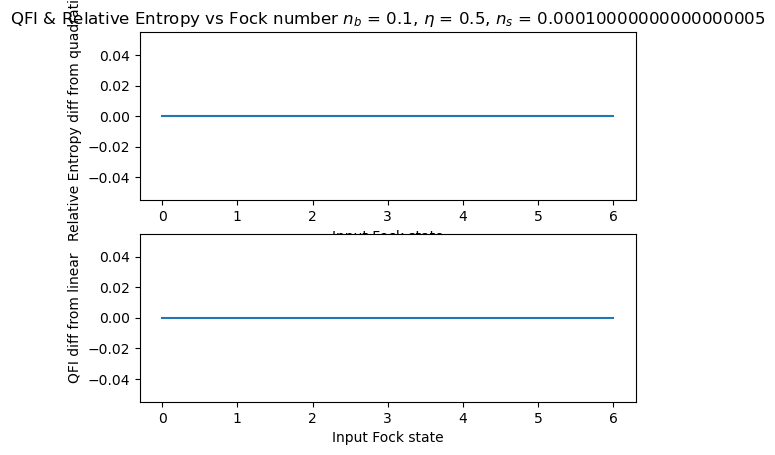

In [12]:
QFIDiff = np.arange(maxphotons)
REDiff = np.arange(maxphotons)
for i in range(maxphotons):
    REDiff[i] = REs[i]-(1+i)**2*REs[0]
    QFIDiff[i] = QFIs[i]-(1+i)*QFIs[0]
fig,ax = plt.subplots(2)
ax[0].set_xlabel('Input Fock state')
ax[1].set_xlabel('Input Fock state')
ax[0].set_ylabel('Relative Entropy diff from quadratic')
ax[1].set_ylabel('QFI diff from linear')
ax[0].set_title(r'QFI & Relative Entropy vs Fock number $n_b$ = {nb}, $\eta$ = {eta}, $n_s$ = {nsq}'.format(nb=nth,eta=eta,nsq = np.sinh(xsi/2)**2))
ax[0].plot(REDiff)
ax[1].plot(QFIDiff)
print(REDiff)

[0.58919579 0.08427495 0.09117713 0.06602098 0.07523957 0.09409158]


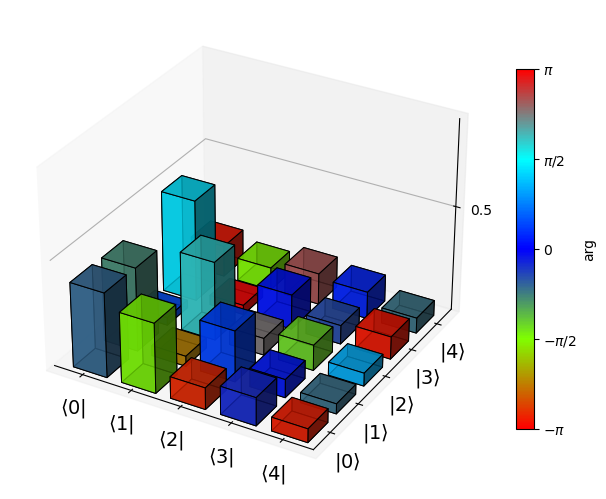

In [13]:
states = []
wdims = 6
sdims = 5
idims = 5
probabilities = np.zeros(wdims)
for i in range(wdims):
    staten = tensor(identity(sdims),identity(idims),basis(wdims,i).dag())*state
    probabilities[i] = staten.norm()**2
    toadd = qutip.dimensions.from_tensor_rep(np.reshape(qutip.dimensions.to_tensor_rep(staten.unit()),[sdims,idims]),[[sdims],[idims]])
    states.append(toadd)
print(probabilities)
[fig,ani] = anim_matrix_histogram(states,bar_style='abs',color_style='phase',options={'bars_alpha':.8})
HTML(ani.to_jshtml())

In [14]:
states = []
wdims = 6
sdims = 5
idims = 5
probabilities = np.zeros(wdims)
n = tensor(num(sdims),identity(idims))
chan = genChannel()
rho = vector_to_operator(chan*operator_to_vector(state.proj()))
QFIs = np.zeros(wdims)
for i in range(wdims):
    staten = (tensor(identity(sdims),identity(idims),basis(wdims,i).dag())*rho*tensor(identity(sdims),identity(idims),basis(wdims,i))).drop_scalar_dims(inplace=True)
    probabilities[i] = staten.norm()
    QFIs[i] = QFI(staten.unit(),n)
print(probabilities)
print(QFIs)
print(np.sum(probabilities*QFIs))

[0.58919579 0.08427495 0.09117713 0.06602098 0.07523957 0.09409158]
[0.08640898 0.35663897 0.32349117 0.34614639 0.29422499 0.26478721]
0.18036706969375127


In [15]:
adverstate = state.ptrace([0])
nbar = expect(num(sdims),adverstate)
print(nbar)
thermeq = thermal_dm(sdims,nbar)
entropy_relative(thermeq,adverstate)

0.5207948264205479


np.float64(0.054165679145548484)

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

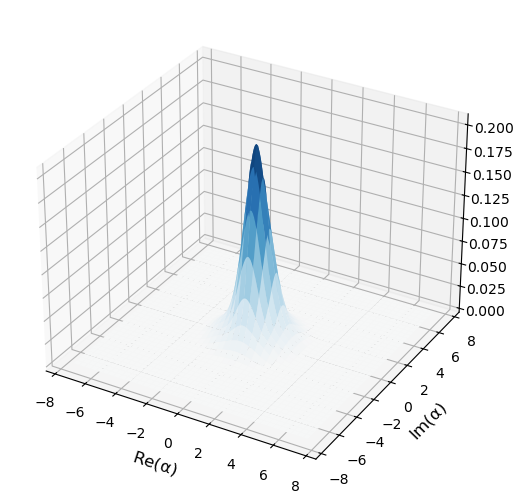

In [16]:
plot_wigner(adverstate,projection='3d')

(<Figure size 640x480 with 1 Axes>,
 <Axes3D: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

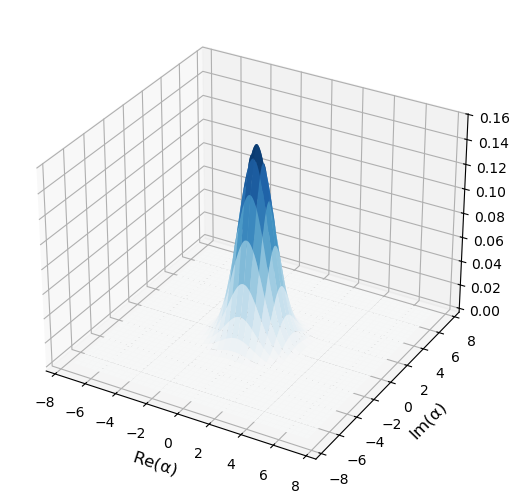

In [17]:
plot_wigner(thermeq,projection='3d')

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='$\\rm{Re}(\\alpha)$', ylabel='$\\rm{Im}(\\alpha)$'>)

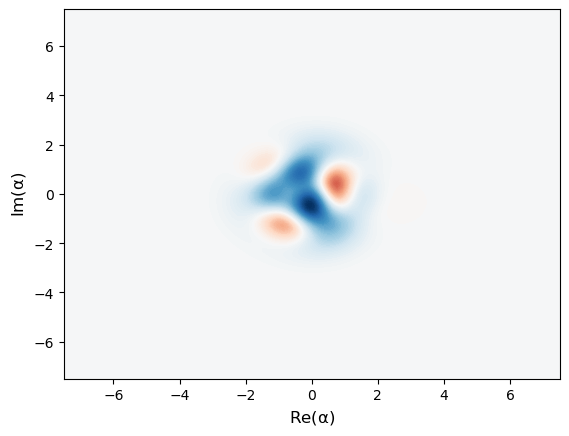

In [18]:
plot_wigner(rand_ket(5))

In [19]:
# Code to generate mixed photon subtracted squeezed states
# that look thermal
def makeSubtractSqueezed(dim = 3, nbright = .01, nsq = .001):
    wdims = dim
    sdims = dim
    idims = dim
    nsamp = nbright/nsq - 1
    a = destroy(sdims)
    iden = identity(sdims)
    zeroket = basis([sdims,idims])
    a1 = tensor(a,iden)

    xsi = 2*np.arcsinh(np.sqrt(nsq))
    S = squeezing(a1,tensor(iden,a),xsi)
    sq = S*zeroket
    if nsamp > 0:
        # populates diagonal terms using truncated operator expression
        beta = np.log(1.0 / nsamp + 1.0)
        diags = [np.exp(-beta * i) for i in range(wdims)]
        diags = diags / np.sum(diags)
        #diags = [nsamp**i/(nsamp+1)**(i+1) for i in range(wdims)]
    else:
        return tensor(sq,basis(wdims))


    ket = 0
    for i in range(wdims):
        unnorm = a1**i * sq
        ket = ket + np.sqrt(diags[i])*tensor(unnorm.unit(),basis(wdims,i))
    return ket

In [20]:
# Code to generate mixed photon subtracted squeezed states
# that look thermal
def makeSubtractSqueezed2(dim=5, nbright = .01, nsamp = .001):
    a = destroy(dim)
    iden = identity(dim)
    zeroket = basis([dim,dim])
    a1 = tensor(a,iden)
    nsq = nbright/(nsamp+1)

    xsi = 2*np.arcsinh(np.sqrt(nsq))
    S = tensor(squeezing(a1,tensor(iden,a),xsi),iden)
    #sq = S*zeroket
    if nsamp > 0:
        # populates diagonal terms using truncated operator expression
        beta = np.log(1.0 / nsamp + 1.0)
        diags = [np.exp(-beta * i) for i in range(dim)]
        diags = np.sqrt(diags / np.sum(diags))
        # diags = [nsamp**i/(nsamp+1)**(i+1) for i in range(dim)]
        #diags = np.sqrt(diags / np.sum(diags))
    else:
        return tensor(sq,basis(dim))


    ket = np.sum([S*tensor(basis(dim),basis(dim,i),basis(dim,i)) for i in range(dim)]*diags)
    return ket

  0%|          | 0/100 [00:00<?, ?it/s]

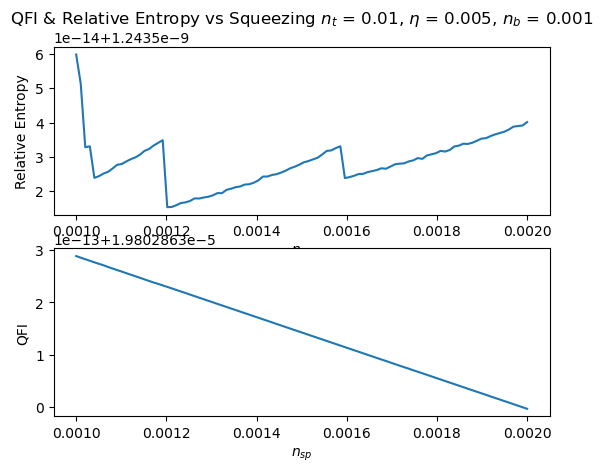

In [21]:
nbright = .001
eta = .005
nth = .01
samples = 100
wdims = 11
sdims = wdims
idims = sdims
chan = genChannel(dims=[sdims,sdims,idims,wdims], params=[eta,nth])
n = tensor(num(sdims),identity(idims),identity(wdims))
pth0 = thermal_dm(sdims,(1-eta)*nth)



QFIs = np.zeros(samples)
REs = np.zeros(samples)
nsamps = np.linspace(.001,.002,samples)
for i in trange(samples):
    ket = makeSubtractSqueezed2(dim=idims,nbright=nbright,nsamp=nsamps[i])
    rho = vector_to_operator(chan*operator_to_vector(ket.proj()))
    QFIs[i] = QFI(rho,n)
    REs[i] = entropy_relative(pth0,rho.ptrace([0]))
fig,ax = plt.subplots(2)
ax[0].set_xlabel(r'$n_{sp}$')
ax[1].set_xlabel(r'$n_{sp}$')
ax[0].set_ylabel('Relative Entropy')
ax[1].set_ylabel('QFI')
ax[0].set_title(r'QFI & Relative Entropy vs Squeezing $n_t$ = {nt}, $\eta$ = {eta}, $n_b$ = {nb}'.format(nt=nth,eta=eta,nb = nbright))
ax[0].plot(nsamps,REs)
ax[1].plot(nsamps,QFIs)

In [22]:
dim=7
ket = makeSubtractSqueezed2(dim=dim,nsamp=.03)
print(ket.norm())
adverstate = ket.proj().ptrace([0])
nbar = expect(num(dim),adverstate)
print(nbar)
thermeq = thermal_dm(dim,nbar)
print(entropy_relative(thermeq,adverstate,tol=1e-200))
a = destroy(dim)
iden = identity(dim)
zeroket = basis([dim,dim])
a1 = tensor(a,iden)
nsq =.01/(1.03)

xsi = 2*np.arcsinh(np.sqrt(nsq))
S = squeezing(a1,tensor(iden,a),xsi)

0.9999999999999999
0.009999999913863949
2.500777362968165e-14


In [23]:
tket = (tensor(identity(dim),identity(dim),fock(dim,3).dag())*ket).drop_scalar_dims(inplace=True).unit()
print(tket)
targetket = (a1**3*S*zeroket).unit()
print(targetket)
print(S)
diff = tket - targetket
print(diff.norm())

Quantum object: dims=[[7, 7], [1]], shape=(49, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.98086168]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.19236298]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.02982066]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.00419206]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]]
Quantum object: dims=[[7, 7], [1]], shape=(49, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.98086173]
 [ 0.        ]
 [ 0.        ]


In [24]:
[_,_,probs] = measurement.measurement_statistics(tket.proj(),tensor(position(dim),position(dim)))

In [25]:
probs

[0.0010466033124227202,
 0.030487834769222708,
 0.010115084921279115,
 0.12795501511414678,
 0.10736110496835835,
 0.09690712184861022,
 0.4463616389659552,
 0.04428670238505237,
 0.08864094765570979,
 0.03524315157817576,
 0.009281377023269248,
 0.002297582077721838,
 1.5835380076575288e-05]

In [26]:
state0 = tensor(coherent(dim,.1),coherent(dim,-.1)).proj()
thetas = np.linspace(.1,2*np.pi-.1,100)
idims = dim
sdims = dim
G = tensor(identity(idims),num(sdims))
op = tensor(position(dim),position(dim))
ath = tensor(destroy(dim),identity(dim))
asi = tensor(identity(dim),destroy(dim)) # can't call this as, because it's a keyword
GU = np.pi *1j*(ath.dag()*asi +asi.dag()*ath)/2
    # Define the beamsplitter transform
U = GU.expm()
#op = U*tensor(num(dim),num(dim))*U.dag()
[_,_,probs0] = measurement.measurement_statistics(state0,op)
numprobs = len(probs0)
def for_jacobian_lin(theta):
    U = (1j*theta[0]*G).expm()
    state = U*state0*U.dag()
    [_,_,probs] = measurement.measurement_statistics(state,op)
    logprob = np.log(probs)
    return logprob
def for_jacobian(thetas):
    print(np.shape(thetas))
    return np.apply_along_axis(for_jacobian_lin, axis=0, arr=thetas)
def getprobs(thetas):
    output = np.zeros((numprobs,len(thetas)))
    for i in range(len(thetas)):
        U = (1j*thetas[i]*G).expm()
        state = U*state0*U.dag()
        [_,_,probs] = measurement.measurement_statistics(state,op)
        output[:,i] = probs
    return output
FI_observable(state0,G,op,[.01,2*np.pi-.01])
#print(np.shape(for_jacobian(thetas)))
res = sp.differentiate.jacobian(for_jacobian,np.reshape(thetas,(1,100)))
dlogp = res.df[:,0,:]
probs = getprobs(thetas)
expects = np.sum(dlogp**2*probs,axis=0)
FI = np.max(expects)
thetamax = thetas[np.argmax(expects)]

(1, 1, 100)
(1, 1, 100, 8)
(1, 1, 100, 2)
(1, 1, 100, 2)


In [27]:
FI

np.float64(0.001539180305927641)

In [28]:
thetamax

np.float64(4.708473717560293)

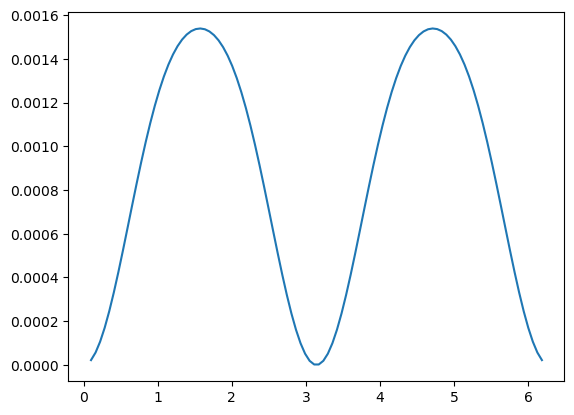

In [29]:
plt.plot(thetas,expects)

In [30]:
QFI(state0,G)

np.float64(0.040000000000000875)

In [31]:
np.shape(np.reshape(thetas,(1,1,100)))[1:]

(1, 100)